In [1]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    print(dirname)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/zeynepdemirta
/kaggle/input/datasets/zeynepdemirta/ciciomt2024-attacks
/kaggle/input/datasets/zeynepdemirta/ciciomt2024-attacks/csv
/kaggle/input/datasets/zeynepdemirta/ciciomt2024-attacks/csv/test
/kaggle/input/datasets/zeynepdemirta/ciciomt2024-attacks/csv/train


Combined dataset: (8775013, 46)

Class distribution:
Label
DDoS-UDP                   1998026
DDoS-ICMP                  1887175
DDoS-TCP                    987063
DDoS-SYN                    974359
DoS-UDP                     704503
DoS-SYN                     540498
DoS-ICMP                    514724
DoS-TCP                     462480
Benign                      230339
MQTT-DDoS-Connect_Flood     214952
Recon-Port_Scan             106603
MQTT-DoS-Publish_Flood       52881
MQTT-DDoS-Publish_Flood      36039
Recon-OS_Scan                20666
ARP_Spoofing                 17791
MQTT-DoS-Connect_Flood       15904
MQTT-Malformed_Data           6877
Recon-VulScan                 3207
Recon-Ping_Sweep               926
Name: count, dtype: int64

Sampled dataset: (800000, 46)
Numeric features: 45

Binary: Benign=21,000 | Attack=779,000
Classes (19): ['ARP_Spoofing', 'Benign', 'DDoS-ICMP', 'DDoS-SYN', 'DDoS-TCP', 'DDoS-UDP', 'DoS-ICMP', 'DoS-SYN', 'DoS-TCP', 'DoS-UDP', 'MQTT-DDoS-Connect_Floo

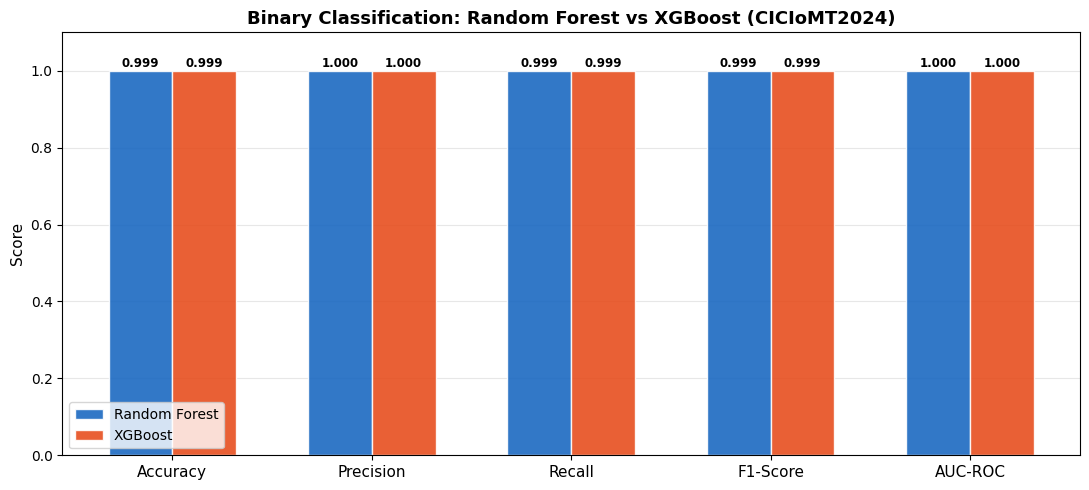

Saved: metrics_comparison.png


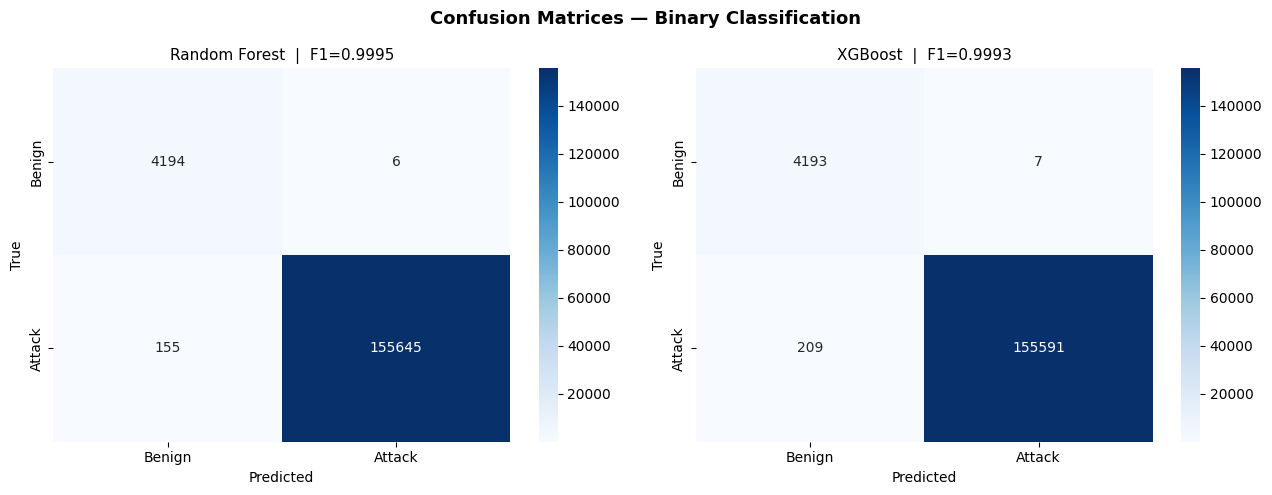


=== NOVELTY 1: PER-ATTACK-CATEGORY SHAP ===
Attack categories found: ['DDoS', 'DoS', 'Recon', 'MQTT', 'Spoofing']


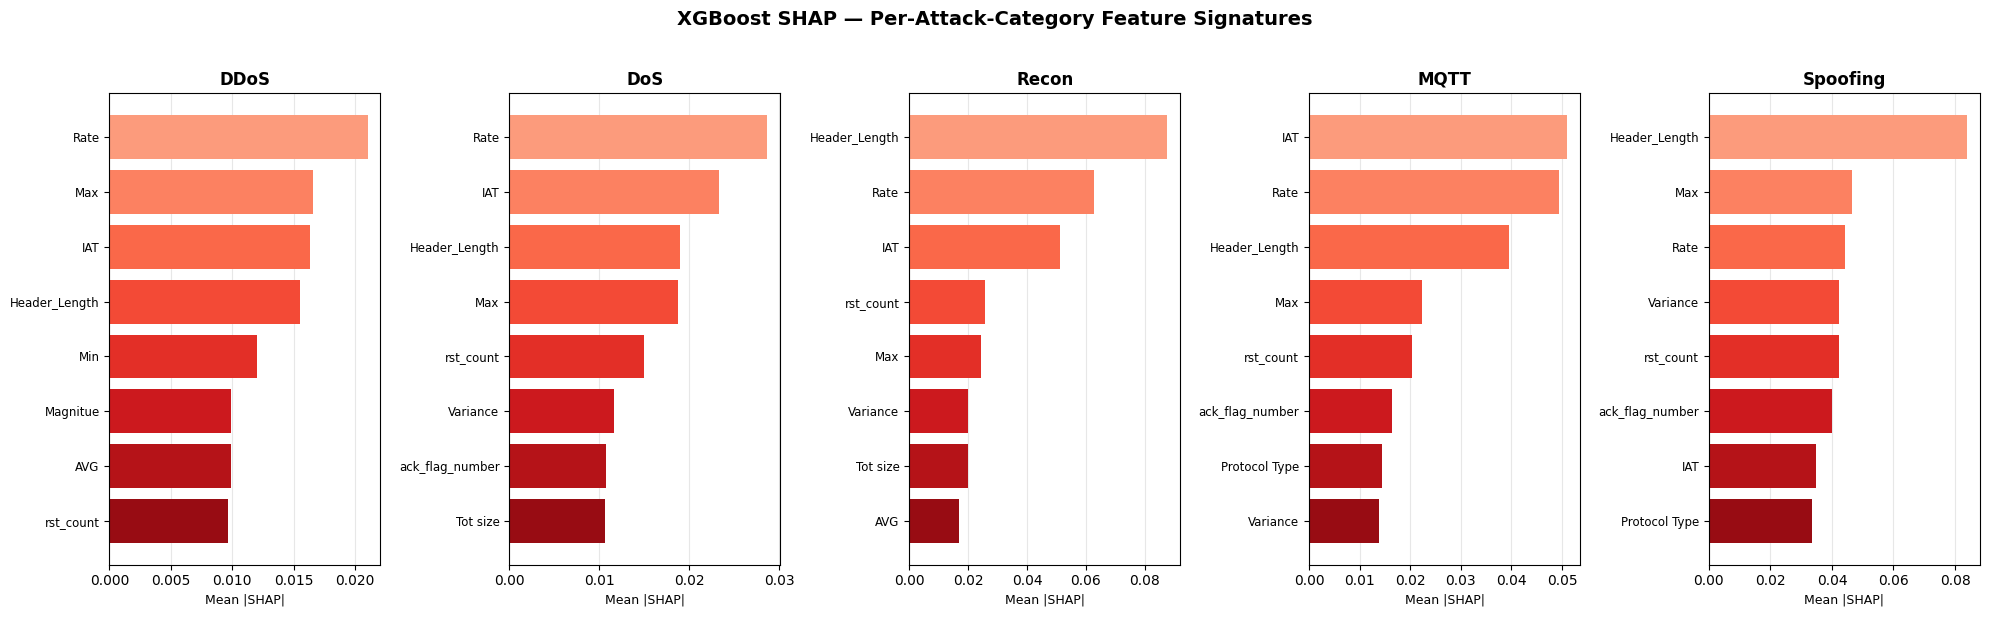

Saved: shap_per_attack_category.png

📊 Feature Signatures Per Attack Category (Top 5):
--------------------------------------------------------------------------------
  DDoS        : Rate, Max, IAT, Header_Length, Min
  DoS         : Rate, IAT, Header_Length, Max, rst_count
  Recon       : Header_Length, Rate, IAT, rst_count, Max
  MQTT        : IAT, Rate, Header_Length, Max, rst_count
  Spoofing    : Header_Length, Max, Rate, Variance, rst_count
--------------------------------------------------------------------------------

=== NOVELTY 2: SHAP RANK AGREEMENT (RF vs XGBoost) ===

Feature Ranking Agreement:
                 RF Rank  XGBoost Rank  RF |SHAP|  XGB |SHAP|  Rank Diff
rst_count              1             2   0.069700    1.287263          1
Magnitue               2             1   0.069646    3.872041          1
IAT                    3             7   0.056128    0.872817          4
AVG                    4             4   0.051794    1.067201          0
Tot size          

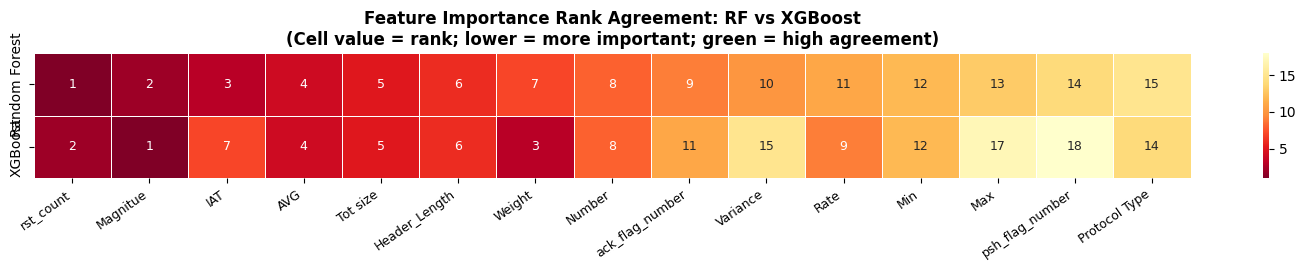

Saved: shap_rank_agreement_heatmap.png

Features with rank difference ≤ 2: 13/20 (65% agreement)

=== NOVELTY 3: SHAP EXPLANATION STABILITY ===
  Trial 1/5 complete
  Trial 2/5 complete
  Trial 3/5 complete
  Trial 4/5 complete
  Trial 5/5 complete


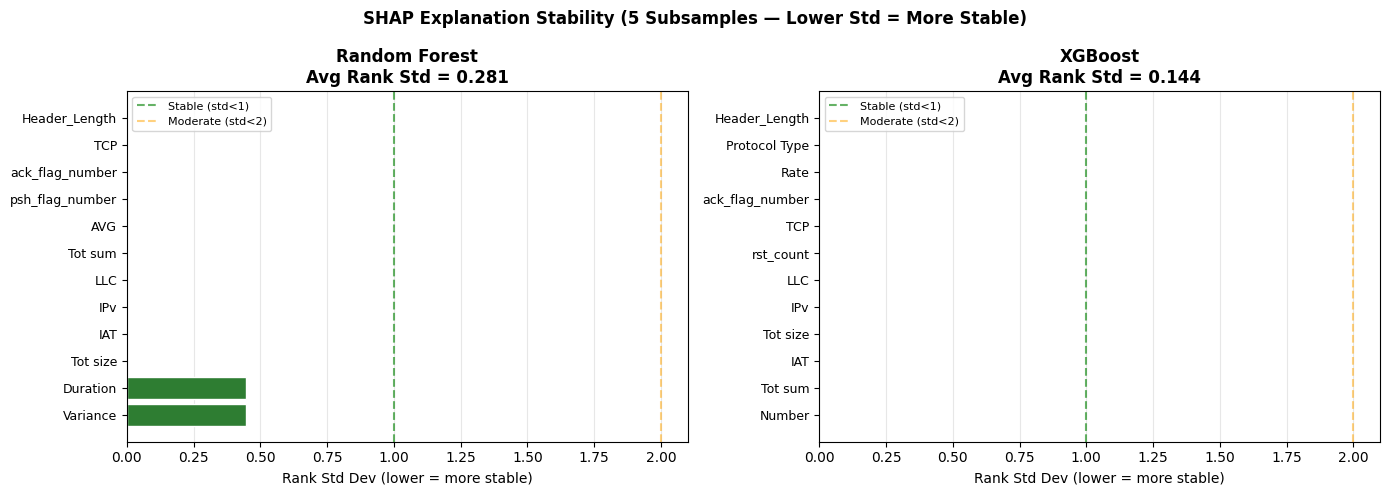

Saved: shap_stability.png

📊 Stability Summary:
  Random Forest: Avg Rank Std = 0.281  ✅ Highly Stable
  XGBoost: Avg Rank Std = 0.144  ✅ Highly Stable

=== STANDARD SHAP PLOTS ===


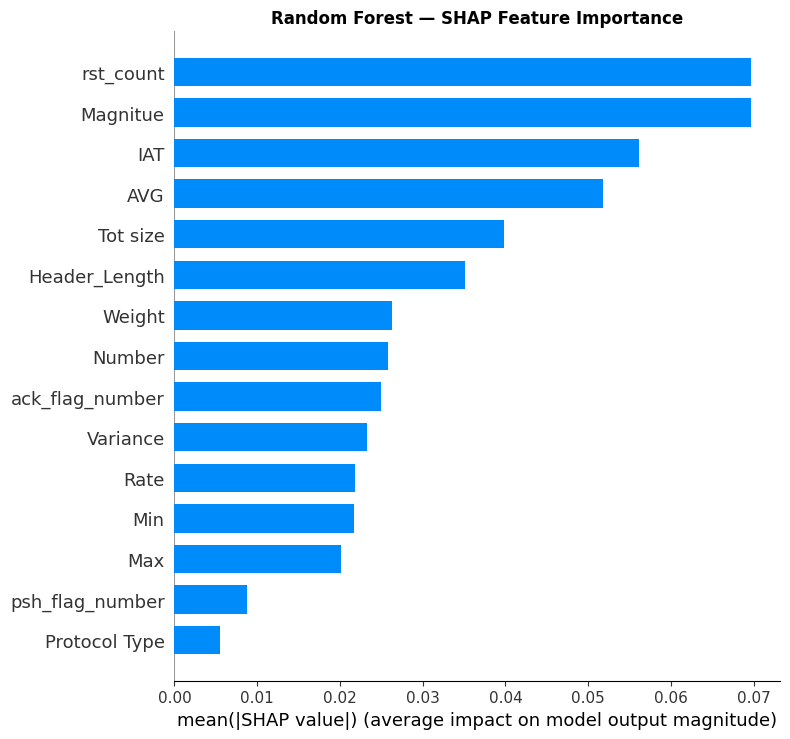

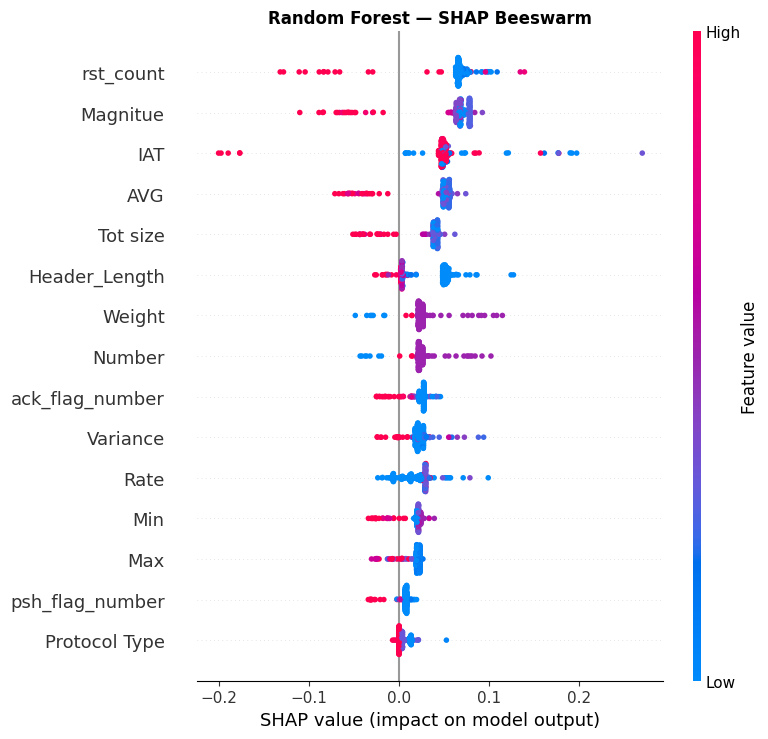

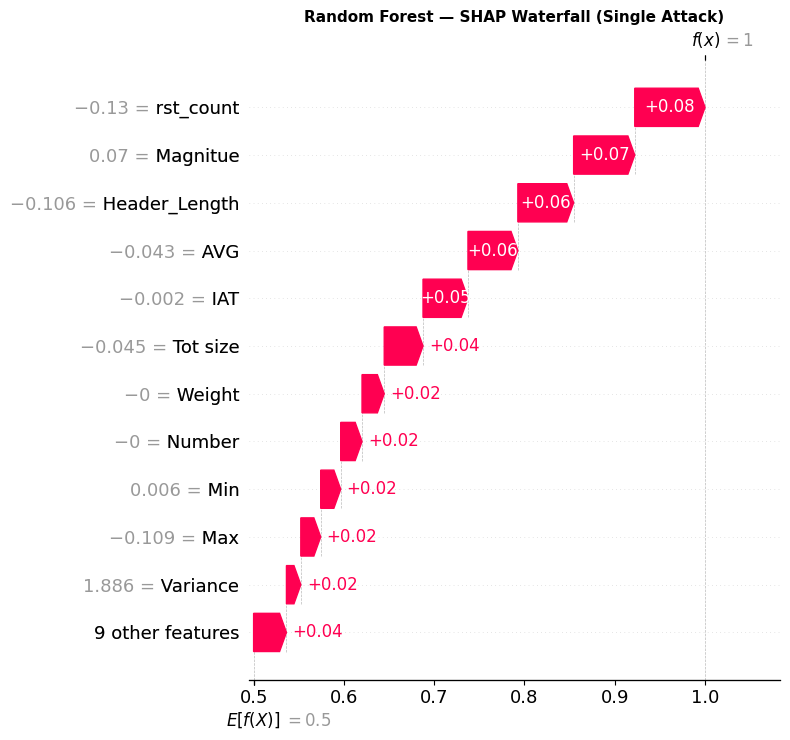

  Saved all SHAP plots for Random Forest


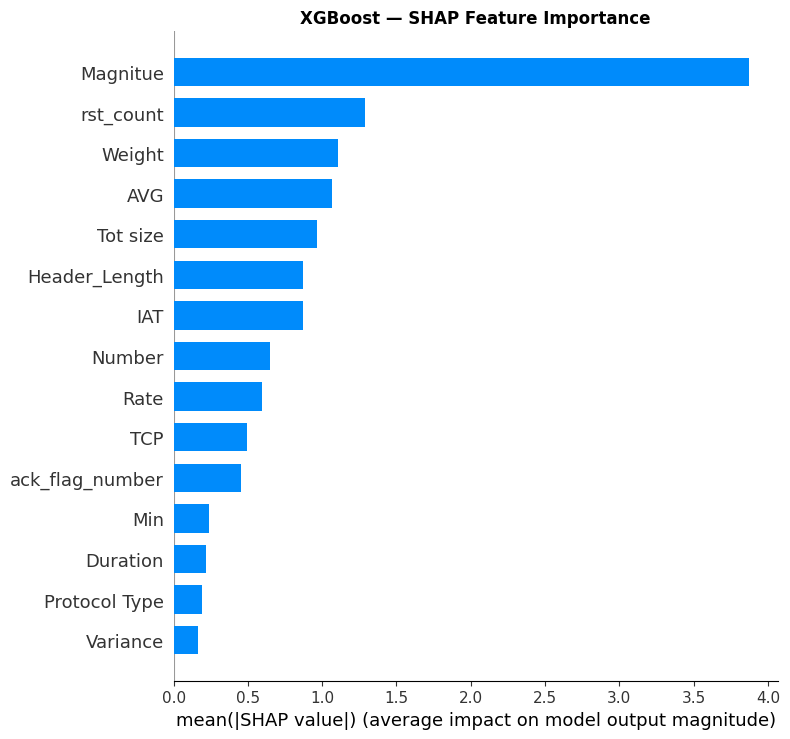

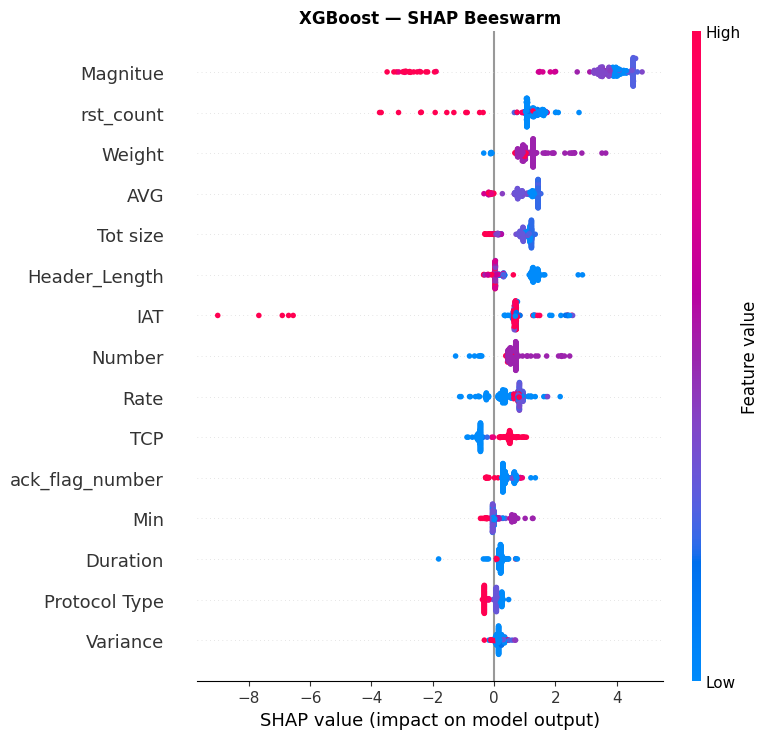

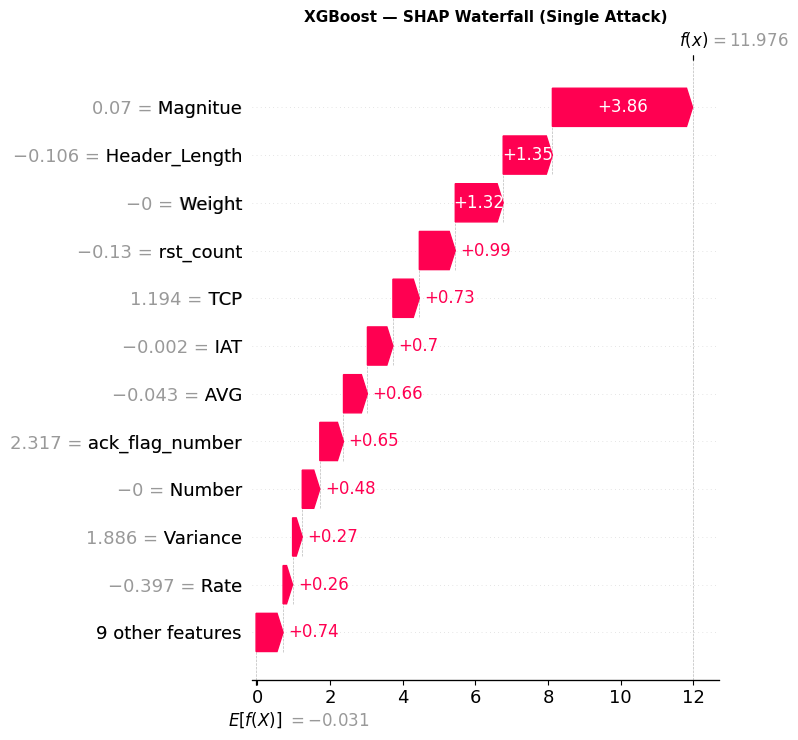

  Saved all SHAP plots for XGBoost

FINAL RESULTS SUMMARY
       Task         Model Accuracy Precision Recall F1-Score AUC-ROC
     Binary Random Forest   0.9990    1.0000 0.9990   0.9995  0.9999
     Binary       XGBoost   0.9987    1.0000 0.9987   0.9993  1.0000
Multi-class Random Forest   0.2266    0.1474 0.2266   0.1021  0.5016
Multi-class       XGBoost   0.2266    0.1337 0.2266   0.1037  0.5004

✅ ALL OUTPUTS SAVED:
   metrics_comparison.png       → Table II bar chart
   confusion_matrices.png       → Confusion matrix figure
   shap_per_attack_category.png → NOVELTY 1 figure ★
   shap_rank_agreement_heatmap.png → NOVELTY 2 figure ★
   shap_stability.png           → NOVELTY 3 figure ★
   shap_bar_*.png               → Standard SHAP bar plots
   shap_beeswarm_*.png          → Standard beeswarm plots
   shap_waterfall_*.png         → Single-instance waterfall
   results_summary.csv          → Numbers for Table II
   shap_model_agreement.csv     → Numbers for Novelty 2 table


In [5]:
# ============================================================
# Explainable Anomaly Detection in IoMT
# Random Forest vs XGBoost + SHAP (3 Novelty Upgrades)
# Dataset: CICIoMT2024
# ============================================================

# ── CELL 1: Imports ─────────────────────────────────────────
# !pip install shap -q

import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from collections import Counter

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report)
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

warnings.filterwarnings("ignore")
np.random.seed(42)
shap.initjs()

# ── CELL 2: Load CSVs + Extract Label from Filename ─────────
# CICIoMT2024 has NO label column inside the CSV.
# The attack type IS the filename prefix, e.g.:
#   TCP_IP-DDoS-ICMP1_train.pcap.csv  → label = "DDoS-ICMP"
#   Benign_train.pcap.csv              → label = "Benign"
#   ARP_Spoofing_train.pcap.csv        → label = "ARP_Spoofing"

def extract_label_from_filename(filename):
    """Extract attack category from CICIoMT2024 filename."""
    base = os.path.basename(filename)
    # Remove suffixes: _train.pcap.csv or _test.pcap.csv
    base = base.replace("_train.pcap.csv", "").replace("_test.pcap.csv", "")
    # Remove trailing digits (e.g. ICMP1 → ICMP, SYN3 → SYN)
    import re
    base = re.sub(r'\d+$', '', base)
    # Remove TCP_IP- prefix
    base = base.replace("TCP_IP-", "")
    # Clean up trailing dashes/underscores
    base = base.strip("-_")
    return base

frames = []
for root, dirs, files in os.walk("/kaggle/input"):
    for f in files:
        if not f.endswith(".csv"):
            continue
        path = os.path.join(root, f)
        try:
            df_tmp = pd.read_csv(path, low_memory=False)
            label = extract_label_from_filename(f)
            df_tmp["Label"] = label
            frames.append(df_tmp)
        except Exception as e:
            print(f"Skipping {f}: {e}")

df = pd.concat(frames, ignore_index=True)
label_col = "Label"

print(f"Combined dataset: {df.shape}")
print(f"\nClass distribution:\n{df[label_col].value_counts()}")

# Sample to 800k rows for Kaggle memory limits
MAX_ROWS = 800_000
if len(df) > MAX_ROWS:
    # Stratified sample to keep all classes
    df = df.groupby(label_col, group_keys=False).apply(
        lambda x: x.sample(frac=MAX_ROWS/len(df), random_state=42)
    ).reset_index(drop=True)
    print(f"\nSampled dataset: {df.shape}")

# ── CELL 3: Preprocessing ────────────────────────────────────
X = df.drop(columns=[label_col])

# Drop text/IP columns
for c in list(X.columns):
    if X[c].dtype == object and X[c].nunique() > 50:
        X = X.drop(columns=[c])

# Clean
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median(numeric_only=True))
X = X.select_dtypes(include=[np.number])
print(f"Numeric features: {X.shape[1]}")

# Binary label: Benign=0, Attack=1
y_bin = (df[label_col].str.lower() != "benign").astype(int)
print(f"\nBinary: Benign={sum(y_bin==0):,} | Attack={sum(y_bin==1):,}")

# Multi-class label
le = LabelEncoder()
y_multi = le.fit_transform(df[label_col])
class_names = list(le.classes_)
print(f"Classes ({len(class_names)}): {class_names}")

# Feature selection via Mutual Information (top 20)
selector = SelectKBest(mutual_info_classif, k=min(20, X.shape[1]))
selector.fit(X, y_bin)
X = X.loc[:, selector.get_support()]
feat_names = list(X.columns)
print(f"\nSelected features: {feat_names}")

# Scale
scaler = StandardScaler()
X = pd.DataFrame(scaler.fit_transform(X), columns=feat_names)
print(f"Feature matrix: {X.shape}")

# ── CELL 4: Train-Test Split + SMOTE ─────────────────────────
X_train, X_test, yb_train, yb_test = train_test_split(
    X, y_bin, test_size=0.2, stratify=y_bin, random_state=42)
_, _, ym_train, ym_test = train_test_split(
    X, y_multi, test_size=0.2, stratify=y_multi, random_state=42)

try:
    sm = SMOTE(random_state=42)
    X_train_sm, yb_train_sm = sm.fit_resample(X_train, yb_train)
    print(f"After SMOTE: {Counter(yb_train_sm)}")
except Exception as e:
    X_train_sm, yb_train_sm = X_train, yb_train
    print(f"SMOTE skipped: {e}")

# ── CELL 5: Train Binary Models ───────────────────────────────
bin_models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=120, max_depth=20, n_jobs=-1, random_state=42),
    "XGBoost": XGBClassifier(
        n_estimators=120, max_depth=6, learning_rate=0.1,
        eval_metric="logloss", verbosity=0, random_state=42)
}

bin_results = {}
for name, model in bin_models.items():
    print(f"\nTraining {name} (binary)...")
    model.fit(X_train_sm, yb_train_sm)
    preds = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    bin_results[name] = {
        "Accuracy":  accuracy_score(yb_test, preds),
        "Precision": precision_score(yb_test, preds, zero_division=0),
        "Recall":    recall_score(yb_test, preds, zero_division=0),
        "F1":        f1_score(yb_test, preds, zero_division=0),
        "AUC":       roc_auc_score(yb_test, proba),
        "preds":     preds
    }
    print(f"  Acc={bin_results[name]['Accuracy']:.4f}  "
          f"F1={bin_results[name]['F1']:.4f}  "
          f"AUC={bin_results[name]['AUC']:.4f}")
    print(classification_report(yb_test, preds,
          target_names=["Benign","Attack"], zero_division=0))

# ── CELL 6: Train Multi-class Models ──────────────────────────
multi_models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=120, max_depth=20, n_jobs=-1, random_state=42),
    "XGBoost": XGBClassifier(
        n_estimators=120, max_depth=6, learning_rate=0.1,
        eval_metric="mlogloss", verbosity=0, random_state=42)
}

multi_results = {}
for name, model in multi_models.items():
    print(f"\nTraining {name} (multi-class)...")
    model.fit(X_train, ym_train)
    preds = model.predict(X_test)
    try:
        auc = roc_auc_score(ym_test, model.predict_proba(X_test),
                            multi_class="ovr", average="macro")
    except:
        auc = 0.0
    multi_results[name] = {
        "Accuracy":  accuracy_score(ym_test, preds),
        "Precision": precision_score(ym_test, preds, average="weighted", zero_division=0),
        "Recall":    recall_score(ym_test, preds, average="weighted", zero_division=0),
        "F1":        f1_score(ym_test, preds, average="weighted", zero_division=0),
        "AUC":       auc,
        "preds":     preds
    }
    print(f"  Acc={multi_results[name]['Accuracy']:.4f}  "
          f"F1={multi_results[name]['F1']:.4f}  "
          f"AUC={multi_results[name]['AUC']:.4f}")

# ── CELL 7: Metrics Bar Chart ─────────────────────────────────
metrics = ["Accuracy", "Precision", "Recall", "F1", "AUC"]
x = np.arange(len(metrics))
w = 0.32
colors = ["#1565C0", "#E64A19"]

fig, ax = plt.subplots(figsize=(11, 5))
for i, (name, color) in enumerate(zip(bin_results.keys(), colors)):
    vals = [bin_results[name][m] for m in metrics]
    bars = ax.bar(x + i*w, vals, w, label=name, color=color, alpha=0.88, edgecolor="white")
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
                f"{v:.3f}", ha="center", va="bottom", fontsize=8.5, fontweight="bold")

ax.set_xticks(x + w/2)
ax.set_xticklabels(["Accuracy","Precision","Recall","F1-Score","AUC-ROC"], fontsize=11)
ax.set_ylim(0, 1.10)
ax.set_ylabel("Score", fontsize=11)
ax.set_title("Binary Classification: Random Forest vs XGBoost (CICIoMT2024)",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.yaxis.grid(True, alpha=0.3); ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig("metrics_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: metrics_comparison.png")

# ── CELL 8: Confusion Matrices ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Confusion Matrices — Binary Classification", fontsize=13, fontweight="bold")
for ax, (name, res) in zip(axes, bin_results.items()):
    cm = confusion_matrix(yb_test, res["preds"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Benign","Attack"], yticklabels=["Benign","Attack"])
    ax.set_title(f"{name}  |  F1={res['F1']:.4f}", fontsize=11)
    ax.set_ylabel("True"); ax.set_xlabel("Predicted")
plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

# ══════════════════════════════════════════════════════════════
# ── NOVELTY 1: Per-Attack-Category SHAP ──────────────────────
# Shows which features are unique signatures for each attack type
# No prior CICIoMT2024 paper has done this
# ══════════════════════════════════════════════════════════════
print("\n=== NOVELTY 1: PER-ATTACK-CATEGORY SHAP ===")

xgb_multi = multi_models["XGBoost"]
X_shap_multi = X_test.sample(min(400, len(X_test)), random_state=42).reset_index(drop=True)

explainer_multi = shap.TreeExplainer(xgb_multi)
sv_multi = explainer_multi.shap_values(X_shap_multi)
# sv_multi shape: (n_samples, n_features, n_classes)

# Map class names to attack categories
attack_categories = {
    "DDoS":     [i for i,c in enumerate(class_names) if "ddos" in c.lower()],
    "DoS":      [i for i,c in enumerate(class_names) if "dos"  in c.lower() and "ddos" not in c.lower()],
    "Recon":    [i for i,c in enumerate(class_names) if "recon" in c.lower() or "scan" in c.lower() or "sweep" in c.lower()],
    "MQTT":     [i for i,c in enumerate(class_names) if "mqtt" in c.lower() or "malformed" in c.lower() or "publish" in c.lower() or "connect" in c.lower()],
    "Spoofing": [i for i,c in enumerate(class_names) if "spoof" in c.lower() or "arp" in c.lower()],
}
# Remove empty categories
attack_categories = {k:v for k,v in attack_categories.items() if len(v)>0}
print(f"Attack categories found: {list(attack_categories.keys())}")

n_cats = len(attack_categories)
fig, axes = plt.subplots(1, n_cats, figsize=(4*n_cats, 6))
if n_cats == 1:
    axes = [axes]
fig.suptitle("XGBoost SHAP — Per-Attack-Category Feature Signatures",
             fontsize=14, fontweight="bold", y=1.02)

top_features_per_attack = {}
for ax, (cat_name, class_indices) in zip(axes, attack_categories.items()):
    # Average |SHAP| across all classes in this category
    cat_shap = np.mean([np.abs(sv_multi[:, :, i]) for i in class_indices], axis=0)
    mean_per_feat = cat_shap.mean(axis=0)

    top_idx  = np.argsort(mean_per_feat)[::-1][:8]
    top_vals = mean_per_feat[top_idx]
    top_feat = [feat_names[i] for i in top_idx]
    top_features_per_attack[cat_name] = top_feat[:5]

    bar_colors = plt.cm.Reds(np.linspace(0.35, 0.9, 8))[::-1]
    ax.barh(range(8), top_vals[::-1], color=bar_colors)
    ax.set_yticks(range(8))
    ax.set_yticklabels(top_feat[::-1], fontsize=8.5)
    ax.set_title(cat_name, fontweight="bold", fontsize=12)
    ax.set_xlabel("Mean |SHAP|", fontsize=9)
    ax.xaxis.grid(True, alpha=0.3); ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("shap_per_attack_category.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: shap_per_attack_category.png")

# Print feature signature comparison table (KEY TABLE FOR PAPER)
print("\n📊 Feature Signatures Per Attack Category (Top 5):")
print("-" * 80)
for cat, feats in top_features_per_attack.items():
    print(f"  {cat:<12}: {', '.join(feats)}")
print("-" * 80)

# ══════════════════════════════════════════════════════════════
# ── NOVELTY 2: RF vs XGBoost SHAP Rank Agreement Heatmap ─────
# Quantifies whether both models agree on which features matter
# ══════════════════════════════════════════════════════════════
print("\n=== NOVELTY 2: SHAP RANK AGREEMENT (RF vs XGBoost) ===")

X_sample = X_test.sample(min(300, len(X_test)), random_state=42).reset_index(drop=True)

def get_shap_1d(model, X_data):
    """Always return a 1D mean |SHAP| array of shape (n_features,)."""
    exp = shap.TreeExplainer(model)
    sv  = exp.shap_values(X_data)
    # list of arrays → binary: take class 1 (attack)
    if isinstance(sv, list):
        sv = sv[1]
    # 3D array (n_samples, n_features, n_classes) → take class 1
    if sv.ndim == 3:
        sv = sv[:, :, 1]
    # now sv is (n_samples, n_features) → mean over samples
    mean_abs = np.abs(sv).mean(axis=0)
    assert mean_abs.ndim == 1, f"Expected 1D, got shape {mean_abs.shape}"
    return mean_abs, exp, sv

rf_mean,  rf_exp,  rf_sv  = get_shap_1d(bin_models["Random Forest"], X_sample)
xgb_mean, xgb_exp, xgb_sv = get_shap_1d(bin_models["XGBoost"],       X_sample)

# Store for reuse in standard plots below
shap_by_model = {
    "Random Forest": {"sv": rf_sv,  "exp": rf_exp,  "mean": rf_mean},
    "XGBoost":       {"sv": xgb_sv, "exp": xgb_exp, "mean": xgb_mean},
}

rf_rank  = pd.Series(rf_mean,  index=feat_names).rank(ascending=False).astype(int)
xgb_rank = pd.Series(xgb_mean, index=feat_names).rank(ascending=False).astype(int)

rank_df = pd.DataFrame({
    "RF Rank":      rf_rank,
    "XGBoost Rank": xgb_rank,
    "RF |SHAP|":    rf_mean,
    "XGB |SHAP|":   xgb_mean,
}).sort_values("RF Rank")
rank_df["Rank Diff"] = abs(rank_df["RF Rank"] - rank_df["XGBoost Rank"])

print("\nFeature Ranking Agreement:")
print(rank_df.to_string())
rank_df.to_csv("shap_model_agreement.csv", index=False)

# Heatmap of top-15 features
top15 = rank_df.head(15)
hmap  = top15[["RF Rank", "XGBoost Rank"]].T

fig, ax = plt.subplots(figsize=(15, 2.8))
sns.heatmap(hmap, annot=True, fmt="d", cmap="YlOrRd_r",
            xticklabels=top15.index, yticklabels=["Random Forest","XGBoost"],
            linewidths=0.5, linecolor="white", ax=ax,
            annot_kws={"fontsize": 9})
ax.set_title("Feature Importance Rank Agreement: RF vs XGBoost\n"
             "(Cell value = rank; lower = more important; green = high agreement)",
             fontsize=12, fontweight="bold")
plt.xticks(rotation=35, ha="right", fontsize=9)
plt.tight_layout()
plt.savefig("shap_rank_agreement_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: shap_rank_agreement_heatmap.png")

# Agreement score
agree = (rank_df["Rank Diff"] <= 2).sum()
print(f"\nFeatures with rank difference ≤ 2: {agree}/{len(rank_df)} ({100*agree/len(rank_df):.0f}% agreement)")

# ══════════════════════════════════════════════════════════════
# ── NOVELTY 3: SHAP Stability Analysis ───────────────────────
# Validates whether explanations are consistent across subsets
# Answers: "Can we trust these explanations?"
# ══════════════════════════════════════════════════════════════
print("\n=== NOVELTY 3: SHAP EXPLANATION STABILITY ===")

N_TRIALS = 5
stability_records = {"Random Forest": [], "XGBoost": []}

for trial in range(N_TRIALS):
    X_sub = X_test.sample(min(200, len(X_test)), random_state=trial*7).reset_index(drop=True)
    for name, model in bin_models.items():
        exp = shap.TreeExplainer(model)
        sv  = exp.shap_values(X_sub)
        # Handle list output (RF binary → [class0, class1])
        if isinstance(sv, list):
            sv = sv[1]
        # Handle 3D array (n_samples, n_features, n_classes) → take class 1
        if sv.ndim == 3:
            sv = sv[:, :, 1]
        # Now sv is guaranteed (n_samples, n_features)
        mean_abs = np.abs(sv).mean(axis=0)   # shape: (n_features,)
        ranking = pd.Series(
            mean_abs, index=feat_names
        ).rank(ascending=False).astype(int)
        stability_records[name].append(ranking)
    print(f"  Trial {trial+1}/{N_TRIALS} complete")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("SHAP Explanation Stability (5 Subsamples — Lower Std = More Stable)",
             fontsize=12, fontweight="bold")

stability_scores = {}
for ax, (name, rankings) in zip(axes, stability_records.items()):
    rank_matrix = pd.DataFrame(rankings)          # (N_TRIALS, n_features)
    rank_std    = rank_matrix.std(axis=0).sort_values()
    stability_scores[name] = rank_std.mean()

    top12 = rank_std.head(12)
    bar_colors = ["#2E7D32" if v < 1.0 else "#F57F17" if v < 2.0 else "#C62828"
                  for v in top12.values]
    ax.barh(range(len(top12)), top12.values[::-1], color=bar_colors[::-1], edgecolor="white")
    ax.set_yticks(range(len(top12)))
    ax.set_yticklabels(top12.index[::-1], fontsize=9)
    ax.set_title(f"{name}\nAvg Rank Std = {stability_scores[name]:.3f}", fontweight="bold")
    ax.set_xlabel("Rank Std Dev (lower = more stable)")
    ax.axvline(x=1.0, color="green",  linestyle="--", alpha=0.6, label="Stable (std<1)")
    ax.axvline(x=2.0, color="orange", linestyle="--", alpha=0.5, label="Moderate (std<2)")
    ax.legend(fontsize=8); ax.xaxis.grid(True, alpha=0.3); ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("shap_stability.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: shap_stability.png")

print("\n📊 Stability Summary:")
for name, score in stability_scores.items():
    tag = "✅ Highly Stable" if score < 1.5 else "⚠️ Moderate" if score < 3.0 else "❌ Unstable"
    print(f"  {name}: Avg Rank Std = {score:.3f}  {tag}")

# ── CELL 12: Standard SHAP Plots (Beeswarm + Waterfall) ──────
print("\n=== STANDARD SHAP PLOTS ===")

for name, model in bin_models.items():
    safe = name.replace(" ", "_")
    sv   = shap_by_model[name]["sv"]
    exp  = shap_by_model[name]["exp"]

    # Bar plot
    plt.figure(figsize=(9, 6))
    shap.summary_plot(sv, X_sample, feature_names=feat_names,
                      plot_type="bar", show=False, max_display=15)
    plt.title(f"{name} — SHAP Feature Importance", fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"shap_bar_{safe}.png", dpi=150, bbox_inches="tight")
    plt.show()

    # Beeswarm
    plt.figure(figsize=(10, 7))
    shap.summary_plot(sv, X_sample, feature_names=feat_names,
                      show=False, max_display=15)
    plt.title(f"{name} — SHAP Beeswarm", fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"shap_beeswarm_{safe}.png", dpi=150, bbox_inches="tight")
    plt.show()

    # Waterfall for one attack instance
    attack_idx = np.where(yb_test.reset_index(drop=True).values == 1)[0]
    if len(attack_idx) > 0:
        base = exp.expected_value
        # expected_value can be: scalar, list, or 1-D array — always extract a float
        if isinstance(base, (list, np.ndarray)):
            base_val = float(np.array(base).flatten()[1])   # index 1 = attack class
        else:
            base_val = float(base)
        sample_i = attack_idx[0] % len(sv)
        expl = shap.Explanation(
            values=sv[sample_i],                            # 1-D (n_features,)
            base_values=base_val,                           # plain Python float
            data=X_sample.iloc[sample_i].values,
            feature_names=feat_names
        )
        plt.figure(figsize=(10, 6))
        shap.waterfall_plot(expl, show=False, max_display=12)
        plt.title(f"{name} — SHAP Waterfall (Single Attack)", fontsize=11, fontweight="bold")
        plt.tight_layout()
        plt.savefig(f"shap_waterfall_{safe}.png", dpi=150, bbox_inches="tight")
        plt.show()
    print(f"  Saved all SHAP plots for {name}")

# ── CELL 13: Final Summary ────────────────────────────────────
print("\n" + "="*60)
print("FINAL RESULTS SUMMARY")
print("="*60)

rows = []
for task, res_dict in [("Binary", bin_results), ("Multi-class", multi_results)]:
    for model_name, res in res_dict.items():
        rows.append({"Task": task, "Model": model_name,
                     "Accuracy":  f"{res['Accuracy']:.4f}",
                     "Precision": f"{res['Precision']:.4f}",
                     "Recall":    f"{res['Recall']:.4f}",
                     "F1-Score":  f"{res['F1']:.4f}",
                     "AUC-ROC":   f"{res['AUC']:.4f}"})

summary_df = pd.DataFrame(rows)
print(summary_df.to_string(index=False))
summary_df.to_csv("results_summary.csv", index=False)

print("\n✅ ALL OUTPUTS SAVED:")
print("   metrics_comparison.png       → Table II bar chart")
print("   confusion_matrices.png       → Confusion matrix figure")
print("   shap_per_attack_category.png → NOVELTY 1 figure ★")
print("   shap_rank_agreement_heatmap.png → NOVELTY 2 figure ★")
print("   shap_stability.png           → NOVELTY 3 figure ★")
print("   shap_bar_*.png               → Standard SHAP bar plots")
print("   shap_beeswarm_*.png          → Standard beeswarm plots")
print("   shap_waterfall_*.png         → Single-instance waterfall")
print("   results_summary.csv          → Numbers for Table II")
print("   shap_model_agreement.csv     → Numbers for Novelty 2 table")